In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder

In [2]:
df = pd.read_csv("../data/Cleaned_Housing_Dataset.csv")
df.columns

Index(['Unnamed: 0', 'Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea',
       'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond

In [3]:
X = df.drop("SalePrice", axis=1)
X.isnull().sum().sort_values(ascending=False)
print(df.isna().sum()[df.isna().sum() > 0])

Series([], dtype: int64)


C:\Users\Rupali Waghmare\AppData\Local\Temp\ipykernel_17108\3174512487.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


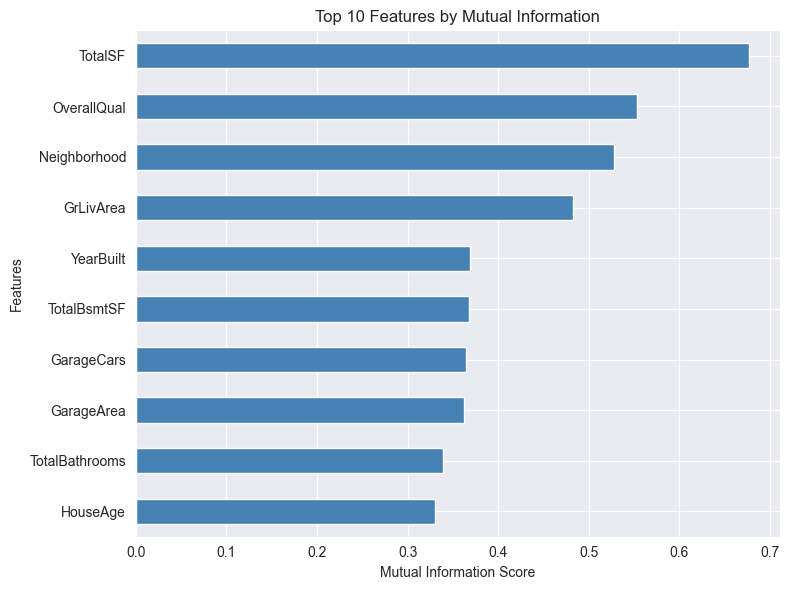

In [4]:

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Get categorical columns
cat_cols = X.select_dtypes(include="object").columns

# Boolean mask for categorical features
discrete_cols = X.columns.isin(cat_cols)

# Temporary encoding
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X[cat_cols] = encoder.fit_transform(X[cat_cols])

# Calculate MI
mi_scores = mutual_info_regression(
    X,
    y,
    discrete_features=discrete_cols,
    random_state=42
)

# Convert to Series and sort
mi_scores = pd.Series(mi_scores, index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

# Top 10 features
top_10 = mi_scores.head(10)

# Plot
plt.figure(figsize=(8, 6))
top_10.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 Features by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

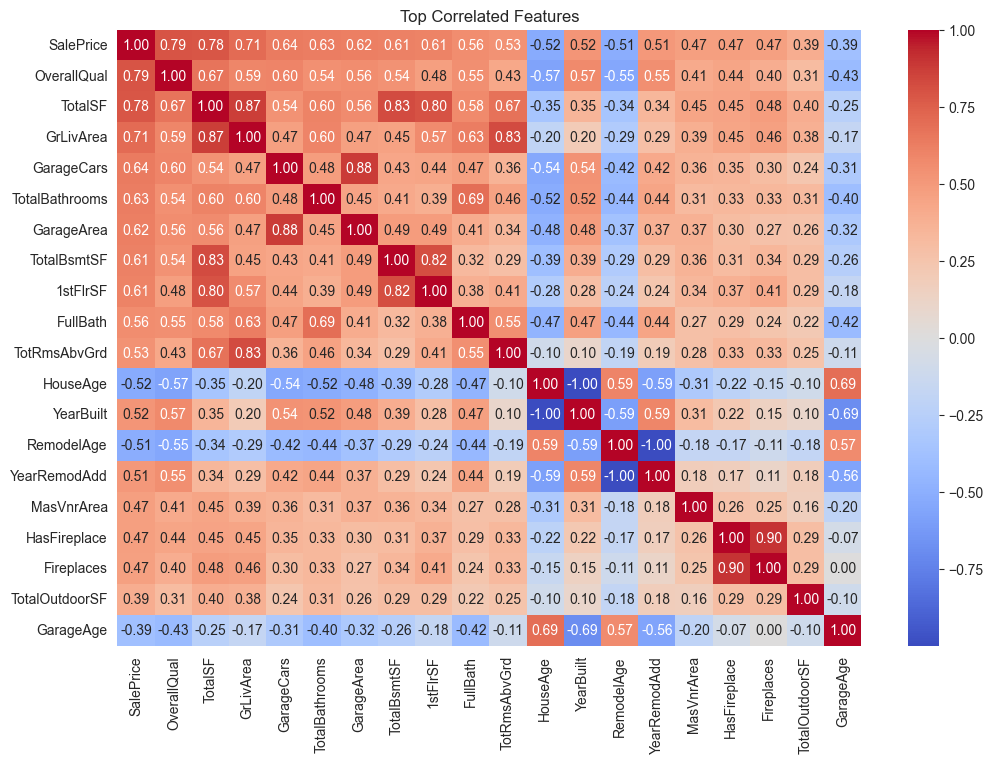

In [5]:
# 1. Correlation Heatmap (Top 20 Features)

corr = df.corr(numeric_only=True)

top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(20).index

plt.figure(figsize=(12,8))
sns.heatmap(
    df[top_corr].corr(),
    annot = True,
    cmap = 'coolwarm',
    fmt = ".2f"
)
plt.title("Top Correlated Features")
plt.show()

# Insights :
# OverallQual, TotalSF, GrLivArea, GarageCars, and GarageArea show the strongest positive correlations with SalePrice, making them the most influential predictors.
# Strong correlations among size-related features indicate multicollinearity, which is more relevant for linear models than tree-based models.

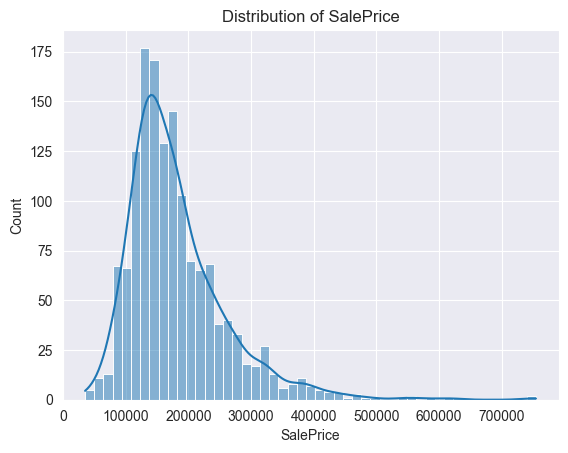

In [6]:
# 2. SalePrice Distribution

sns.histplot(
    data = df,
    x = 'SalePrice',
    kde = True
)
plt.title("Distribution of SalePrice")
plt.show()

# Insights:
# SalePrice is positively skewed, with most houses priced between $100k–$250k and a small number of luxury homes forming a long right tail.
# A log transformation of SalePrice could improve normality and benefit linear regression models.

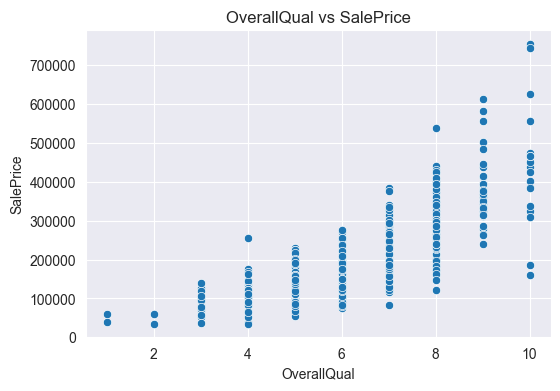

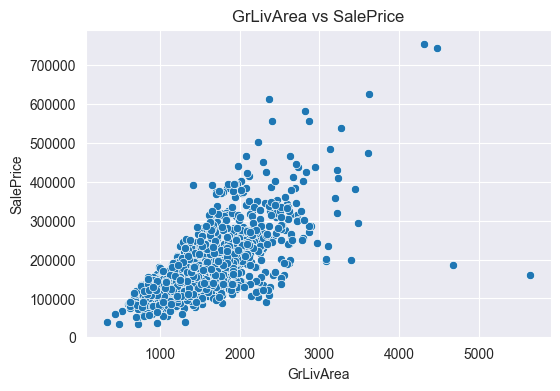

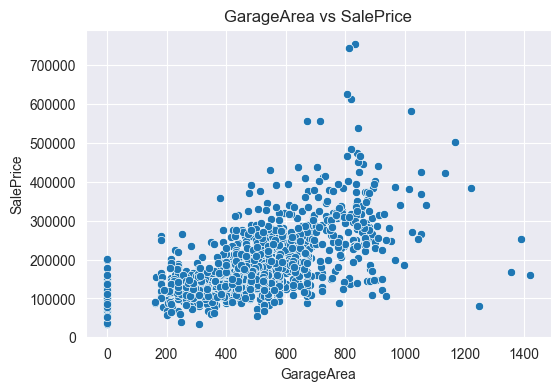

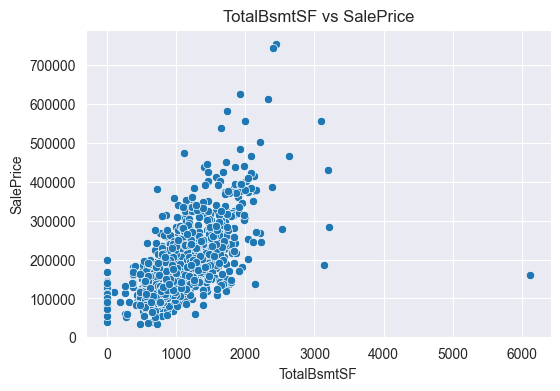

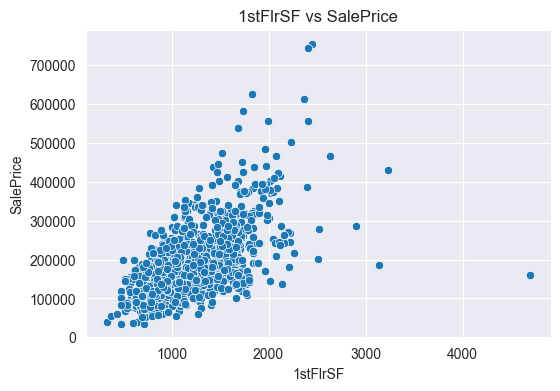

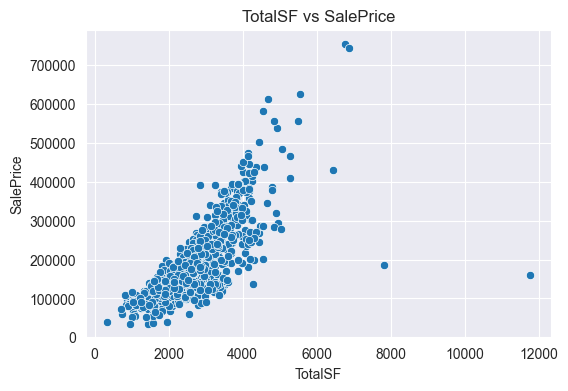

In [7]:
# 3. Numerical Features vs SalePrice

features = [
    "OverallQual",
    "GrLivArea",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "TotalSF"
]

for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(
        x = df[col],
        y = df['SalePrice']
    )
    plt.title(f"{col} vs SalePrice"),
    plt.show()

# Insights:
# All features exhibit a clear positive relationship with SalePrice, confirming that house quality and size significantly influence property value.
# A few extreme observations are visible, particularly for very large houses with relatively low sale prices, indicating potential outliers.

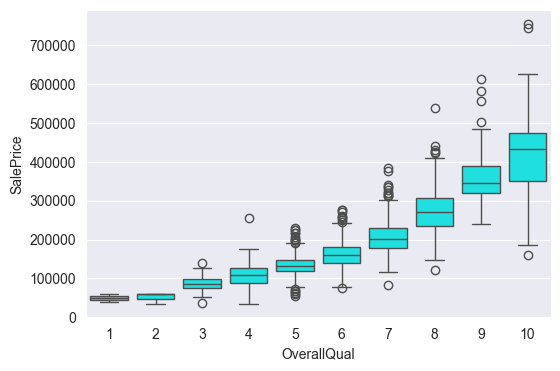

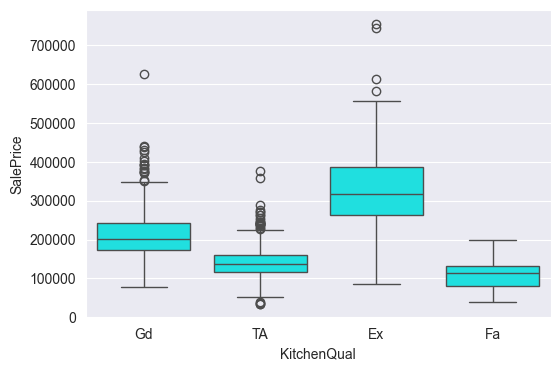

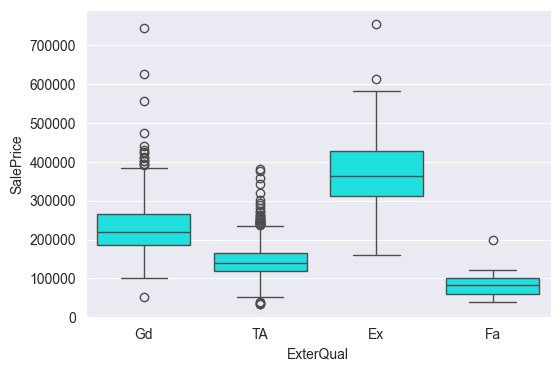

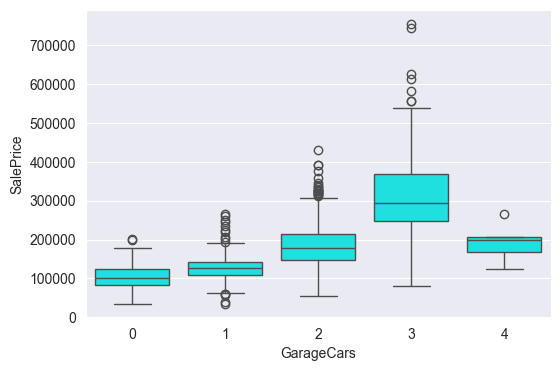

In [8]:
# 4. Boxplots for Important Categorical Features

cat_cols = [
    "OverallQual",
    "KitchenQual",
    "ExterQual",
    "GarageCars"
]

for col in cat_cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(
        x = df[col],
        y = df['SalePrice'],
        showfliers = True,
        color = 'cyan'
    )

# Insights:
# Higher quality ratings and larger garage capacities consistently correspond to higher median sale prices, highlighting their strong impact on house value.
# Price variability increases for premium categories, reflecting greater diversity among high-end properties.

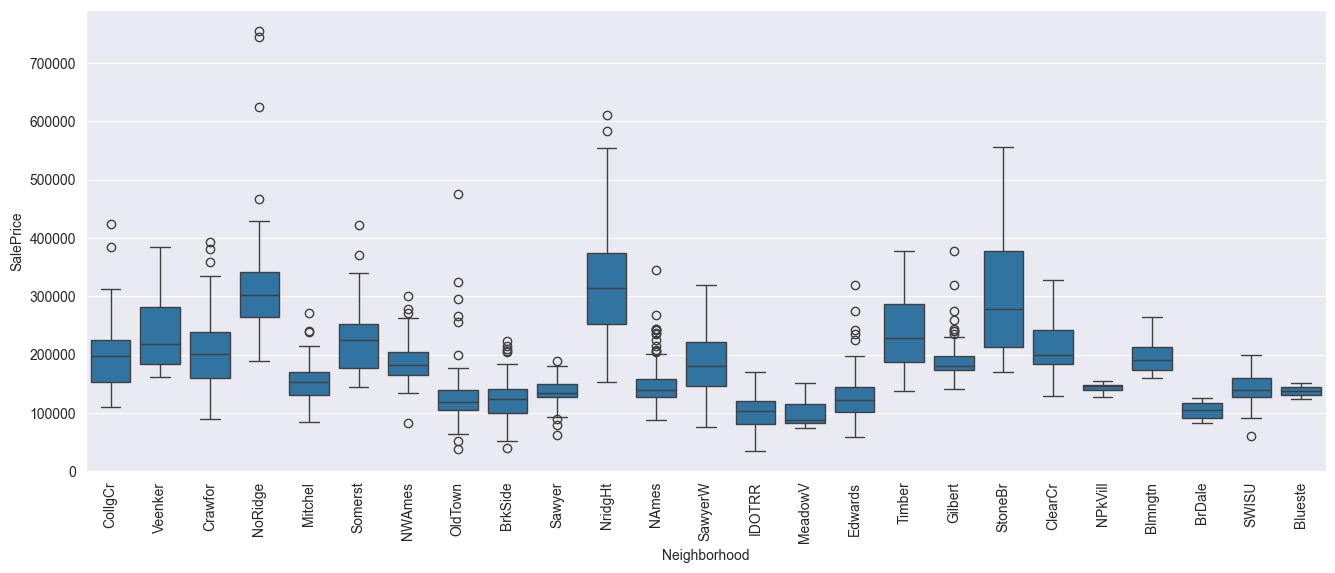

In [9]:
# 5. SalePrice by Neighborhood

plt.figure(figsize=(16,6))
sns.boxplot(
    data = df,
    x="Neighborhood",
    y="SalePrice",
)
plt.xticks(rotation=90)
plt.show()

# Insights:
# House prices vary considerably across neighborhoods, with NridgHt, NoRidge, and StoneBr having the highest median prices.
# Location is one of the strongest categorical factors affecting house prices.

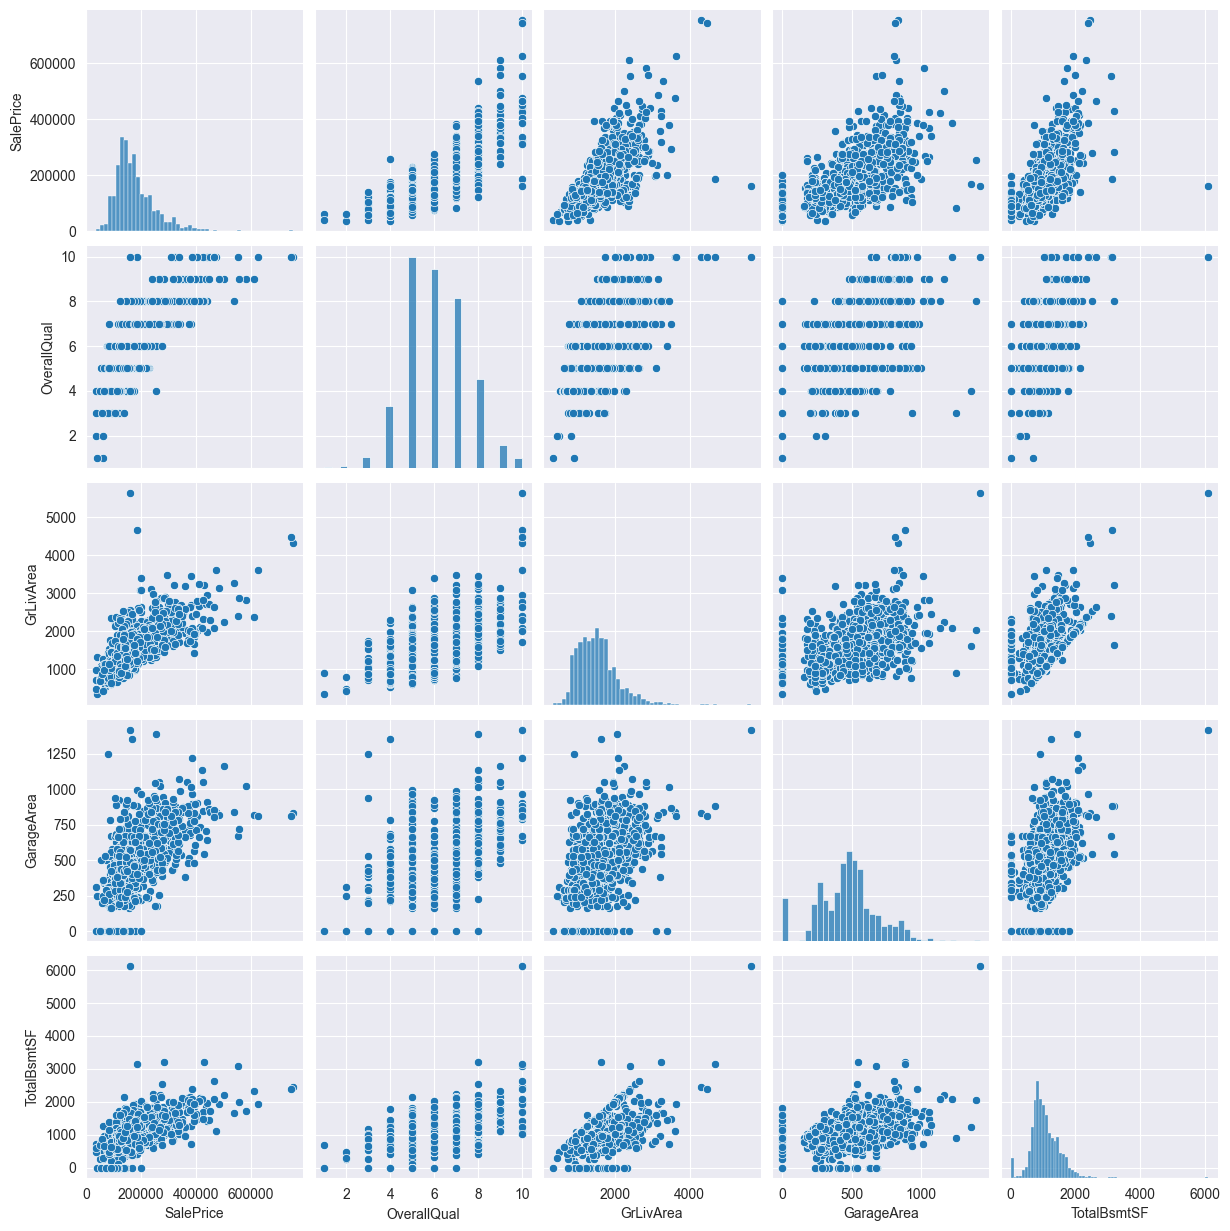

In [10]:
# 6. Pairplot

sns.pairplot(
    df[
        [
            "SalePrice",
            "OverallQual",
            "GrLivArea",
            "GarageArea",
            "TotalBsmtSF"
        ]
    ]
)

# Insights:
# Strong positive relationships exist between SalePrice and major size-related features, while several variables exhibit right-skewed distributions.
# The plots also reveal multicollinearity among size features and highlight a few influential outliers.

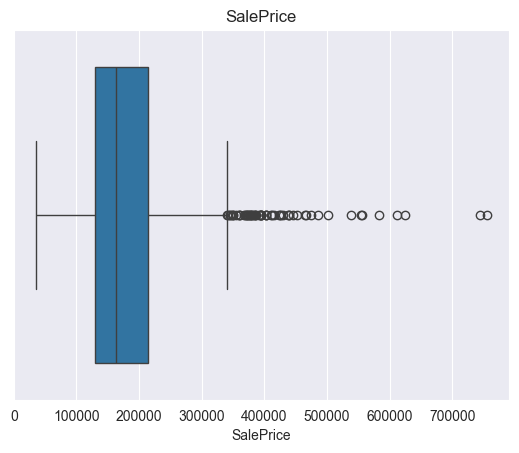

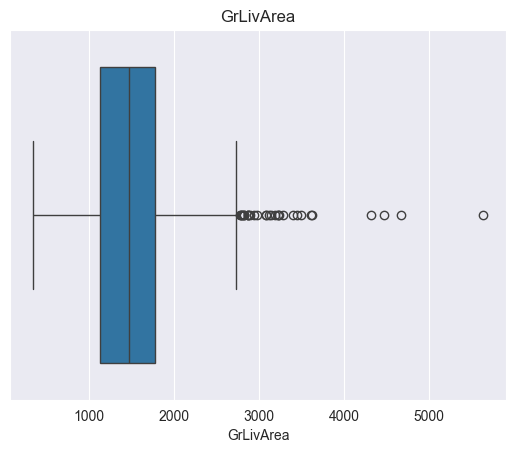

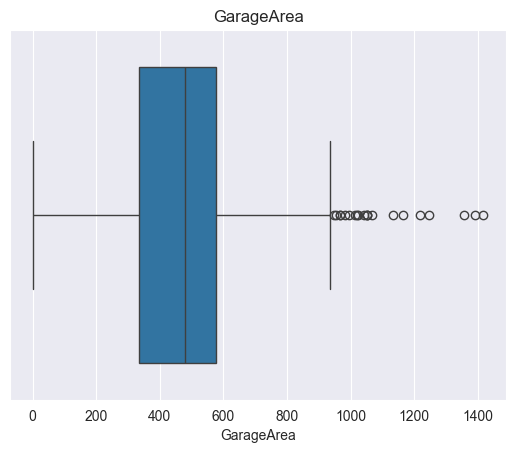

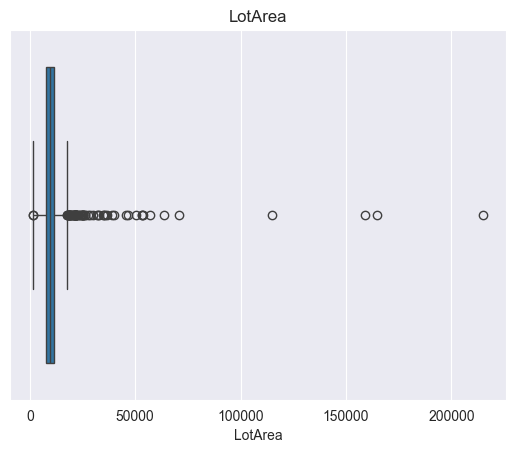

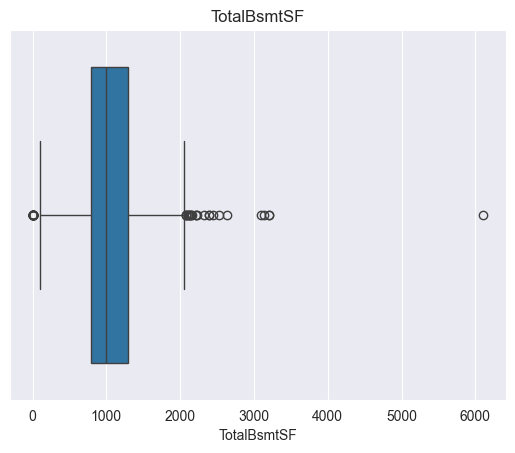

In [11]:
# 7. Outlier Boxplots

cols = [
    "SalePrice",
    "GrLivArea",
    "GarageArea",
    "LotArea",
    "TotalBsmtSF"
]

for col in cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()